In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)
from scipy.sparse import hstack, csr_matrix
pd.set_option('display.max_columns', 50)
print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
file_path='C:\Git_for_study\DE\Practice\Kaggle\Data\Steam Games Dataset\extended_steam_games.csv'
df=pd.read_csv(file_path)
df.head()

,appid,name,developer,publisher,positive,negative,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,release_date,required_age,is_free,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,recommendations,achievements,genres,categories
0,730,Counter-Strike: Global Offensive,Valve,Valve,7642084,1173003,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,1013936,"21 Aug, 2012",0.0,True,"For over two decades, Counter-Strike has offer...","Czech, Danish, Dutch, English<strong>*</strong...",True,False,True,NaN,5211693.0,1.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea..."
1,1172470,Apex Legends,Respawn,Electronic Arts,668053,326926,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,124262,"4 Nov, 2020",0.0,True,"Apex Legends is the award-winning, free-to-pla...","English<strong>*</strong>, French<strong>*</st...",True,False,False,88.0,1580.0,12.0,"Action, Adventure, Free To Play","Multi-player, PvP, Online PvP, Co-op, Online C..."
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",1520457,1037487,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,314682,"21 Dec, 2017",19.0,True,"PUBG: BATTLEGROUNDS, the high-stakes winner-ta...","English, Korean, Simplified Chinese, French, G...",True,False,False,NaN,1762488.0,37.0,"Action, Adventure, Massively Multiplayer, Free...","Multi-player, PvP, Online PvP, Custom Volume C..."
3,1623730,Palworld,Pocketpair,Pocketpair,358266,22443,"50,000,000 .. 100,000,000",0,0,0,0,2999,2999,0,18028,"Jul 9, 2026",0.0,False,"Fight, farm, build and work alongside mysterio...","English, Simplified Chinese, Traditional Chine...",True,False,False,NaN,397504.0,75.0,"Action, Adventure, Indie, RPG","Single-player, Multi-player, Co-op, Online Co-..."
4,440,Team Fortress 2,Valve,Valve,1044264,117208,"50,000,000 .. 100,000,000",0,0,0,0,0,0,0,43819,"10 Oct, 2007",0.0,True,Nine distinct classes provide a broad range of...,"English<strong>*</strong>, Danish, Dutch, Finn...",True,False,True,92.0,47647.0,520.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23100 entries, 0 to 23099
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   appid                23100 non-null  int64  
 1   name                 23099 non-null  object 
 2   developer            23034 non-null  object 
 3   publisher            22967 non-null  object 
 4   positive             23100 non-null  int64  
 5   negative             23100 non-null  int64  
 6   owners               23100 non-null  object 
 7   average_forever      23100 non-null  int64  
 8   average_2weeks       23100 non-null  int64  
 9   median_forever       23100 non-null  int64  
 10  median_2weeks        23100 non-null  int64  
 11  price                23100 non-null  int64  
 12  initialprice         23100 non-null  int64  
 13  discount             23100 non-null  int64  
 14  ccu                  23100 non-null  int64  
 15  release_date         22998 non-null 

In [19]:
df.isnull().sum().loc[lambda x : x !=0].sort_values(ascending=False)

metacritic_score       19394
categories               148
publisher                133
genres                   109
release_date             102
short_description         67
developer                 66
supported_languages       63
required_age              48
is_free                   48
platforms_windows         48
platforms_mac             48
platforms_linux           48
recommendations           48
achievements              48
name                       1
dtype: int64

필터링 이후의 게임 상황
label
1    0.729445
0    0.270555
Name: Proportion, dtype: float64


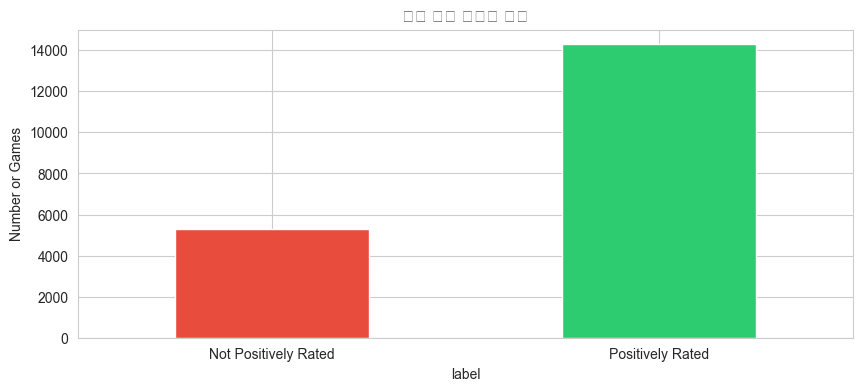

In [23]:
df['total_reviews']=df['positive']+df['negative']
df=df[df['total_reviews']>=20].copy()
df['review_ratio']=df['positive']/df['total_reviews']
df['label']=(df['review_ratio']>=0.7).astype(int)

print('필터링 이후의 게임 상황')
print(df['label'].value_counts(normalize=True).rename('Proportion'))

plt.figure(figsize=(10,4))
df['label'].value_counts().sort_index().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.xticks([0,1], ['Not Positively Rated', 'Positively Rated'], rotation=0)
plt.title('게임 평가 레이블 비중')
plt.ylabel('Number or Games')
plt.show()


지금 이 단계에서 목표 레이블의 비중을 봤으니, 다음은 변수간의 관계가 어떤지 봐야함

In [42]:
df[['recommendations','positive']].corr().iloc[0,1]
leak_cols=['recommendations','positive','negative','total_reviews','review_ratio']
df=df.drop(columns=leak_cols)


KeyError: "None of [Index(['recommendations', 'positive'], dtype='object')] are in the [columns]"

In [43]:
print(f'Dropped columns{leak_cols}')

Dropped columns['recommendations', 'positive', 'negative', 'total_reviews', 'review_ratio']


In [45]:
df.head(3)

,appid,name,developer,publisher,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu,release_date,required_age,is_free,short_description,supported_languages,platforms_windows,platforms_mac,platforms_linux,metacritic_score,achievements,genres,categories,label
0,730,Counter-Strike: Global Offensive,Valve,Valve,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,1013936,"21 Aug, 2012",0.0,True,"For over two decades, Counter-Strike has offer...","Czech, Danish, Dutch, English<strong>*</strong...",True,False,True,NaN,1.0,"Action, Free To Play","Multi-player, Cross-Platform Multiplayer, Stea...",1
1,1172470,Apex Legends,Respawn,Electronic Arts,"100,000,000 .. 200,000,000",0,0,0,0,0,0,0,124262,"4 Nov, 2020",0.0,True,"Apex Legends is the award-winning, free-to-pla...","English<strong>*</strong>, French<strong>*</st...",True,False,False,88.0,12.0,"Action, Adventure, Free To Play","Multi-player, PvP, Online PvP, Co-op, Online C...",0
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.","100,000,000 .. 200,000,000",0,0,0,0,0,0,0,314682,"21 Dec, 2017",19.0,True,"PUBG: BATTLEGROUNDS, the high-stakes winner-ta...","English, Korean, Simplified Chinese, French, G...",True,False,False,NaN,37.0,"Action, Adventure, Massively Multiplayer, Free...","Multi-player, PvP, Online PvP, Custom Volume C...",0


In [62]:
def midpoint_converter(string):
    try:
        lo,hi=str(string).replace(',','').split('..')
        return(int(lo.strip())+int(hi.strip())/2)
    except Exception:
        return np.nan

df['owner_mid']=df['owners'].apply(lambda x: midpoint_converter(x))

df['release_date']=pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']=df['release_date'].dt.year

df['num_languages']=df['supported_languages'].fillna('').apply(
    lambda x: len(x.split(',')) if x else 0
)

df['num_genres']=df['genres'].fillna('').apply(
    lambda x: len([g for g in x.split(',') if g.strip()])
)

df['desc_len']=df['short_description'].fillna('').apply(len)

df['num_categories']=df['categories'].fillna('').apply(
    lambda x: len([c for c in x.split(',') if c.strip()])
)




In [63]:
df['genre_cat_text']=(df['genres'].fillna('')+ ' ' + df['categories'].fillna('')).str.replace(',', ' ')
df['has_metacritic']=df['metacritic_score'].notnull().astype(int)

df['metacritic_score']=df['metacritic_score'].fillna(df['metacritic_score'].median())

for c in ['is_free', 'platforms_windows', 'platforms_mac','platforms_linux']:
    df[c]=df[c].astype(str).map({'True':1, 'False':00}).fillna(0).astype(int)

In [67]:
df['achievements'] = df['achievements'].fillna(0)
df['required_age'] = df['required_age'].fillna(0)
df['owner_mid'] = df['owner_mid'].fillna(df['owner_mid'].median())
df['release_year'] = df['release_year'].fillna(df['release_year'].median())

print("Feature engineering done. Shape now:", df.shape)
df[['owner_mid', 'release_year', 'num_languages', 'desc_len', 'num_genres', 'num_categories']].head()

Feature engineering done. Shape now: (19582, 34)


,owner_mid,release_year,num_languages,desc_len,num_genres,num_categories
0,200000000.0,2012.0,29,224,2,19
1,200000000.0,2020.0,14,284,3,14
2,200000000.0,2017.0,17,248,4,11
3,100000000.0,2019.0,17,157,4,15
4,100000000.0,2007.0,27,169,2,19


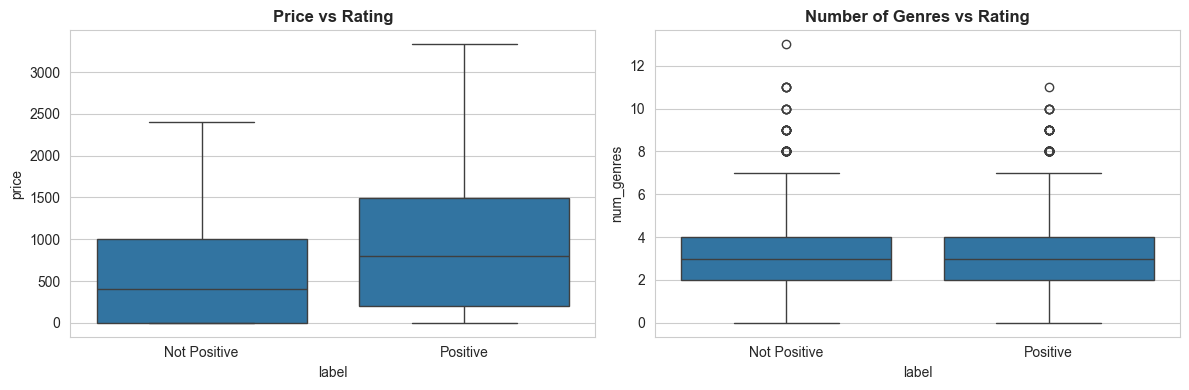

In [71]:
fig, axes=plt.subplots(1,2, figsize=(12,4))
sns.boxplot(data=df, x='label', y='price',  ax=axes[0], showfliers=False)
axes[0].set_xticklabels(['Not Positive', 'Positive'])
axes[0].set_title('Price vs Rating', fontweight='bold')

sns.boxplot(data=df, x='label', y='num_genres', ax=axes[1])
axes[1].set_xticklabels(['Not Positive','Positive'])
axes[1].set_title('Number of Genres vs Rating', fontweight='bold')

plt.tight_layout()
plt.show()

In [1]:
num_features=[
    'price', 'initialprice', 'discount','ccu',
    'average_forever','average_2weeks','median_forever','median_2weeks',
    'required_age','achievements','metacritic_score','has_metacritic',
    'owners_mid','release_year','num_languages','desc_len',
    'num_genres','num_categories',
    'is_free','platforms_windows','platforms_mac','platforms_linux'
]
X_train_df, X_test_df, y_train, y_test=train_test_split(
    df,df['label'], test_size=0.2, random_state=42, stratify=df['label'])

scaler=StandardScaler()
X_train_num=scaler.fit_transform(X_train[num_features])
X_test_num=scaler.transform(X_test_df[num_features])

tfidf=TfidfVectorizer(max_feautres=60, token_pattern=r'[ A-Za-z\-]+')
X_train_text=tfidf.fit_transform(X_trian_df['genre_cat_text'])
X_test_text=tfidf.transform(X_test_df['genre_cat_text'])
## 숫자로 된 변수들을 표준화하고, 텍스트로 된 데이터들도 변수화하기 위하여 Tfidf를 활용함

X_train=hstack([csr_matrix(X_train_num), X_train_text]).tocsr()
X_test=hstack([csr_matrix(X_test_num), X_test_text]).tocsr()

feature_names=num_features+list(tfidf.get_feature_names_out())

print('Train shape:', X_train.shape, "| Test shape:", X_test.shape)



NameError: name 'train_test_split' is not defined

In [ ]:
result={}
trained_models={}

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    preds=model.predict(X_test)
    proba=model.predict_proba(X_test)[:,1]
    
    result[name]={
        'Acuuracy':accuracy_score(y_test, preds),
        'Precision':precision_score(y_test,preds),
        'Recall':recall_score(y_test,preds),
        'F1-Score':f1_score(y_test,pred),
        'ROC-AUC':roc_auc_score(y_test,proba)
    }
    trained_model[name]=model
    print(f'{name} trained')
    return model

In [ ]:
log_reg=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
evaluate_model('Logistic Regression', log_reg)

In [ ]:
rf=RandomForestClassifier(
    n_estimoatr=300, max_depth=14, class_weight='balanced',
    random_state=42, n_jobs=-1
)
evaluate_model('Random Forest Classifier', rf)

In [ ]:
pos_weight=(y_train==0).sum()/(y_train==1).sum()
xgb_model=XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metrics='logloss', random_state=42,
    scale_pos_weight=pos_weight)
evaluate_model('XGBoost', xgb_model)

In [ ]:
lgbm_model=LGBMBClasifier(
    
)